### Preditctions before

I expect Turkish to require the most tokens. It is rich in morphology, and definitely richer than English. With Chinese I'm unsure since it doesn't use latin alphabetic symbols. 
Generally spoken I would expect the representation to be better for all languages with a higher vocabulary. I would assume that the "sweet spot" between vocab size and computation power is at different places. For Chinese I expect that a large vocabulary will lead to having one token per sign or coming closer to that. Since Turkish words can vary much more than English depending on the grammar, I expect some clear suffixes or prefixes that carry information. This goes for english as well, but I expect that pattern to appear early on with a smaller vocabulary.

In [49]:
#Imports
import sentencepiece as spm
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as TorchData
from torch.utils.data import Dataset, DataLoader
import numpy as np
import math
import copy
import matplotlib.pyplot as plt
import pandas
import json
import pprint
from pathlib import Path
import collections
from collections import Counter 

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED = 0

In [2]:
def set_seed(SEED):
    
    # PyTorch seed for CPU
    torch.manual_seed(SEED)
    
    # PyTorch seed for all GPU devices (if using CUDA)
    torch.cuda.manual_seed_all(SEED)
    
    # Make sure to disable CuDNN's non-deterministic optimizations
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [3]:
# Hyperparameters
hyperparameters = {"d_model" : 256,
"n_heads" : 4,
"n_layers" : 2,
"d_ff" : 1024,
"max_seq_len" : 128,
"dropout" : 0.1}

In [4]:
dir_data = Path("/srv/data/lt2326-h26/a1/")
languages = ["en", "tr", "zh"]
models = ["chars", "bpe_7000", "bpe_12000"]
data = {}

for split in ["train", "valid", "test"]:
    data[split] = {}

    for language in languages:
        path = dir_data / split / f"{language}.txt"

        with open(path, encoding="utf-8") as f:
            data[split][language] = [line.strip() for line in f]


In [23]:
# Character tokenizer: one token for each unicode character
sentences_train = (data["train"]["en"] + data["train"]["tr"] + data["train"]["zh"]) #shared vocabulary using train set
sentences_valid = (data["valid"]["en"] + data["valid"]["tr"] + data["valid"]["zh"])
sentences_test = (data["test"]["en"] + data["test"]["tr"] + data["test"]["zh"])

chars = sorted(set("".join(sentences_train)))
char_ID = {"<unk>":0} #unseen tokens
for i, char in enumerate(chars):
    char_ID[char] = i+1

def char_tokenizer(text):
    return[char if char in char_ID else "<unk>" for char in text]

def char_encode(sentence):
    return [char_ID.get(char, char_ID["<unk>"]) for char in sentence]

print(char_tokenizer(data["valid"]["zh"][0]))

['，', '也', '是', '一', '所', '专', '门', '提', '供', '研', '究', '生', '及', '以', '上', '级', '别', '课', '程', '的', '私', '立', '精', '英', '级', '大', '学', '。']


In [6]:
with open ("train_BPE", "w", encoding="utf-8") as f: 
    #first create a file that contains all sentences using the shared vocab from earlier
    for sentence in sentences_train:
        f.write(sentence + "\n")

### Choice of BPE sizes
I settled for 7.000 and 12.000 tokens which is at least for the smaller model much more than the suggested 2.000. Initially this was becasue I ran into a issue with the deafault character coverage of sentencePiece, which is 0.9995. I lowered the coverage to fit a model of 4.000, but to keep the models comparable I would have to use the lowered coveregae for both models even though the large BPE model would not have any issue with the default coverage. Therefore I choose a higher token count for both models so that they can work with the default coverage. 
Regarding the languages in specific this is important becasue Chinese has much more unique tokens than English and Turkish as we can see in the cells below when I print examples from every model for every langauge. A lower coverage would mean that more unique tokens would end up in "<unk>". Since the difference between the amount of merges in the languages is interesting to me, I made this decision for now. I might change it again after the evaluation to see what the impact actually was if I have the time.

In [7]:
#BPE Tokenizer: vocab size = 7.000
spm.SentencePieceTrainer.train(
    input="./train_BPE", 
    model_prefix='bpe_7000', 
    vocab_size=7000,
    model_type="bpe",
   character_coverage=0.9995, 
)


sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: ./train_BPE
  input_format: 
  model_prefix: bpe_7000
  model_type: BPE
  vocab_size: 7000
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_vocab_limit: 1
  use_all_vocab: 0
  unk_id: 0
  bos_id: 1
  eos_id: 2
  pad_id: -1
  unk_piece: <unk>
  bos_piece: <s>
  eos_piece: </s>
  pad_piece: <pad>
  unk_surface:  ⁇ 
  enable_differential_privacy: 0
  differenti

In [8]:
#BPE Tokenizer: vocab size = 12.000
spm.SentencePieceTrainer.train(
    input="./train_BPE", 
    model_prefix='bpe_12000', 
    vocab_size=12000,
    model_type="bpe",
   character_coverage=0.9995, 
)

sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: ./train_BPE
  input_format: 
  model_prefix: bpe_12000
  model_type: BPE
  vocab_size: 12000
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_vocab_limit: 1
  use_all_vocab: 0
  unk_id: 0
  bos_id: 1
  eos_id: 2
  pad_id: -1
  unk_piece: <unk>
  bos_piece: <s>
  eos_piece: </s>
  pad_piece: <pad>
  unk_surface:  ⁇ 
  enable_differential_privacy: 0
  differen

In [9]:
# Analyze the tokenizers
bpe_7000 = spm.SentencePieceProcessor(model_file='bpe_7000.model')
bpe_12000 = spm.SentencePieceProcessor(model_file='bpe_12000.model')

# Vocab size
if "<eos>" not in char_ID:
    char_ID["<eos>"] = len(char_ID)
    eos_C = char_ID["<eos>"]
vocab_size_char = len(char_ID)
vocab_size_S = bpe_7000.get_piece_size()
vocab_size_L = bpe_12000.get_piece_size()

# Writing a function to get the statistics for each tokenizer
def get_stats(text, tokenizer, vocab_size):
    tok_sentences = [tokenizer(sentence) for sentence in text]
    total_tokens = sum(len(tokens) for tokens in tok_sentences)
    average_tokens_sent = total_tokens/len(text)
    total_char = sum(len(sentence) for sentence in text)
    average_tokens_char = total_char/total_tokens
    return {
        "vocabulary size": vocab_size,
        "total number of tokens": total_tokens,
        "average tokens per sentence": average_tokens_sent,
        "average character per token": average_tokens_char
    }
print("Report on the statistics of the character tokenizer for English, Turkish and Chinese:")
print(get_stats(data["valid"]["en"], char_tokenizer, vocab_size_char))
print(get_stats(data["valid"]["tr"], char_tokenizer, vocab_size_char))
print(get_stats(data["valid"]["zh"], char_tokenizer, vocab_size_char))

print("Report on the statistics of the smaller BPE tokenizer for English, Turkish and Chinese:")
print(get_stats(data["valid"]["en"], lambda sentence: bpe_7000.encode(sentence, out_type=str), vocab_size_S))
print(get_stats(data["valid"]["tr"], lambda sentence: bpe_7000.encode(sentence, out_type=str), vocab_size_S))
print(get_stats(data["valid"]["zh"], lambda sentence: bpe_7000.encode(sentence, out_type=str), vocab_size_S))

print("Report on the statistics of the larger BPE tokenizer for English, Turkish and Chinese:")
print(get_stats(data["valid"]["en"], lambda sentence: bpe_12000.encode(sentence, out_type=str), vocab_size_L))
print(get_stats(data["valid"]["tr"], lambda sentence: bpe_12000.encode(sentence, out_type=str), vocab_size_L))
print(get_stats(data["valid"]["zh"], lambda sentence: bpe_12000.encode(sentence, out_type=str), vocab_size_L))

def count_unk_bpe(sp, sents):
    return sum(id == sp.unk_id() for sentence in sents for id in sp.encode(sentence, out_type=int))

def count_unk_char(sents):
    return sum(character not in char_ID for sentence in sents for character in sentence)

rows = []
tokenizers_table = {
    "char":      (char_tokenizer,
                  vocab_size_char,
                  lambda sents: count_unk_char(sents)),
    "bpe_7000":  (lambda s: bpe_7000.encode(s, out_type=str),
                  vocab_size_S,
                  lambda sents: count_unk_bpe(bpe_7000, sents)),
    "bpe_12000": (lambda s: bpe_12000.encode(s, out_type=str),
                  vocab_size_L,
                  lambda sents: count_unk_bpe(bpe_12000, sents))}

for name, (tok, v, unk_fn) in tokenizers_table.items():
    for lang in languages:
        sents = data["valid"][lang]
        rows.append({"tokenizer": name,
                     "language": lang,
                     **get_stats(sents, tok, v),
                     "unk": unk_fn(sents)})
pandas.DataFrame(rows)


Report on the statistics of the character tokenizer for English, Turkish and Chinese:
{'vocabulary size': 9444, 'total number of tokens': 368269, 'average tokens per sentence': 81.11651982378855, 'average character per token': 1.0}
{'vocabulary size': 9444, 'total number of tokens': 368383, 'average tokens per sentence': 98.62998661311914, 'average character per token': 1.0}
{'vocabulary size': 9444, 'total number of tokens': 368266, 'average tokens per sentence': 38.545740004186726, 'average character per token': 1.0}
Report on the statistics of the smaller BPE tokenizer for English, Turkish and Chinese:
{'vocabulary size': 7000, 'total number of tokens': 170571, 'average tokens per sentence': 37.57070484581498, 'average character per token': 2.1590364129893125}
{'vocabulary size': 7000, 'total number of tokens': 176974, 'average tokens per sentence': 47.38259705488621, 'average character per token': 2.0815656537118445}
{'vocabulary size': 7000, 'total number of tokens': 346060, 'aver

,tokenizer,language,vocabulary size,total number of tokens,average tokens per sentence,average character per token,unk
0,char,en,9444,368269,81.116520,1.000000,49
1,char,tr,9444,368383,98.629987,1.000000,15
2,char,zh,9444,368266,38.545740,1.000000,258
3,bpe_7000,en,7000,170571,37.570705,2.159036,26
4,bpe_7000,tr,7000,176974,47.382597,2.081566,14
5,bpe_7000,zh,7000,346060,36.221478,1.064168,732
6,bpe_12000,en,12000,118361,26.070705,3.111405,26
7,bpe_12000,tr,12000,117310,31.408300,3.140252,14
8,bpe_12000,zh,12000,294015,30.774021,1.252542,732


Both BPEs have the same counts of unknown characters. This was one of my main reasonings for choosing my BPE sizes.

In [10]:
# Print our some example sentences with different tokenizers
# English
print("ENGLISH")
sentence_en = data["valid"]["en"][0]
print(f"Original English:\n {sentence_en}")
print(f"Character tokenizer:\n {char_tokenizer(sentence_en)}")
print(f"Smaller BPE:\n {bpe_7000.encode(sentence_en, out_type=str)}")
print(f"Larger BPE:\n {bpe_12000.encode(sentence_en, out_type=str)}")

# Turkish
print("\nTURKISH")
sentence_tr = data["valid"]["tr"][0]
print(f"Original Turkish:\n {sentence_tr}")
print(f"Character tokenizer:\n {char_tokenizer(sentence_tr)}")
print(f"Smaller BPE:\n {bpe_7000.encode(sentence_tr, out_type=str)}")
print(f"Larger BPE:\n {bpe_12000.encode(sentence_tr, out_type=str)}")

# Chinese
print("\nCHINESE")
sentence_zh = data["valid"]["zh"][0]
print(f"Original Chinese:\n {sentence_zh}")
print(f"Character tokenizer:\n {char_tokenizer(sentence_zh)}")
print(f"Smaller BPE:\n {bpe_7000.encode(sentence_zh, out_type=str)}")
print(f"Larger BPE:\n {bpe_12000.encode(sentence_zh, out_type=str)}")


ENGLISH
Original English:
 She played in two matches at this championship.
Character tokenizer:
 ['S', 'h', 'e', ' ', 'p', 'l', 'a', 'y', 'e', 'd', ' ', 'i', 'n', ' ', 't', 'w', 'o', ' ', 'm', 'a', 't', 'c', 'h', 'e', 's', ' ', 'a', 't', ' ', 't', 'h', 'i', 's', ' ', 'c', 'h', 'a', 'm', 'p', 'i', 'o', 'n', 's', 'h', 'i', 'p', '.']
Smaller BPE:
 ['▁She', '▁play', 'ed', '▁in', '▁t', 'wo', '▁m', 'at', 'c', 'he', 's', '▁at', '▁this', '▁ch', 'amp', 'ions', 'h', 'ip', '.']
Larger BPE:
 ['▁She', '▁played', '▁in', '▁two', '▁mat', 'ches', '▁at', '▁this', '▁ch', 'ampionship', '.']

TURKISH
Original Turkish:
 Germantown akademisine devam ettikten sonra 1869-1870 yılları Fransa ve Almanya'da okullarda geçti.
Character tokenizer:
 ['G', 'e', 'r', 'm', 'a', 'n', 't', 'o', 'w', 'n', ' ', 'a', 'k', 'a', 'd', 'e', 'm', 'i', 's', 'i', 'n', 'e', ' ', 'd', 'e', 'v', 'a', 'm', ' ', 'e', 't', 't', 'i', 'k', 't', 'e', 'n', ' ', 's', 'o', 'n', 'r', 'a', ' ', '1', '8', '6', '9', '-', '1', '8', '7', '0', ' ', '

In [25]:
# Now i need to encode all sentences in train and validation data
# Becasue I will have to batch them for the transformer I need tor preserve the beginning/end of a sentence.

tokenizer_S = bpe_7000
tokenizer_L = bpe_12000

train_encoded_C = [char_encode(sentence) + [eos_C] for sentence in sentences_train]
valid_encoded_C = [char_encode(sentence) + [eos_C] for sentence in sentences_valid]
test_encoded_C = [char_encode(sentence) + [eos_C] for sentence in sentences_test]

train_encoded_S = [tokenizer_S.encode(sentence, out_type=int) +[tokenizer_S.eos_id()] for sentence in sentences_train]
valid_encoded_S = [tokenizer_S.encode(sentence, out_type=int) +[tokenizer_S.eos_id()] for sentence in sentences_valid]
test_encoded_S = [tokenizer_S.encode(sentence, out_type=int) + [tokenizer_S.eos_id()] for sentence in sentences_test]

train_encoded_L = [tokenizer_L.encode(sentence, out_type=int) +[tokenizer_L.eos_id()] for sentence in sentences_train]
valid_encoded_L = [tokenizer_L.encode(sentence, out_type=int) +[tokenizer_L.eos_id()] for sentence in sentences_valid]      
test_encoded_L = [tokenizer_L.encode(sentence, out_type=int) + [tokenizer_L.eos_id()] for sentence in sentences_test]

In [27]:
# Batching the lists of sentences I just made to the size of 128 tokens per batch
def flatten_sents(encoded_sentences):  
    all_tokens = []
    for sentence in encoded_sentences:
        all_tokens.extend(sentence)
    return all_tokens

train_flattened_C = flatten_sents(train_encoded_C)
valid_flattened_C = flatten_sents(valid_encoded_C)
test_flattened_C = flatten_sents(test_encoded_C)

train_flattened_S = flatten_sents(train_encoded_S)
valid_flattened_S = flatten_sents(valid_encoded_S)
test_flattened_S = flatten_sents(test_encoded_S)

train_flattened_L = flatten_sents(train_encoded_L)
valid_flattened_L = flatten_sents(valid_encoded_L)
test_flattened_L = flatten_sents(test_encoded_L)

In [13]:
class BuildDataset(Dataset):
    def __init__ (self, tokens, seq_len):
        self.tokens = torch.tensor(tokens, dtype=torch.long)
        self.seq_len = seq_len

    def __len__(self):
        return (len(self.tokens) -1) // self.seq_len

    def __getitem__(self, idx):
        start = idx * self.seq_len
        chunk = self.tokens[start:start + self.seq_len +1]

        x = chunk[:-1]
        y = chunk[1:]
        return x, y

In [29]:
train_dataset_C = BuildDataset(train_flattened_C, seq_len=hyperparameters["max_seq_len"])
train_dataset_S = BuildDataset(train_flattened_S, seq_len=hyperparameters["max_seq_len"])
train_dataset_L = BuildDataset(train_flattened_L, seq_len=hyperparameters["max_seq_len"])

valid_dataset_C = BuildDataset(valid_flattened_C, seq_len=hyperparameters["max_seq_len"])
valid_dataset_S = BuildDataset(valid_flattened_S, seq_len=hyperparameters["max_seq_len"])
valid_dataset_L = BuildDataset(valid_flattened_L, seq_len=hyperparameters["max_seq_len"])

test_dataset_C = BuildDataset(test_flattened_C, seq_len=hyperparameters["max_seq_len"])
test_dataset_S = BuildDataset(test_flattened_S, seq_len=hyperparameters["max_seq_len"])
test_dataset_L = BuildDataset(test_flattened_L, seq_len=hyperparameters["max_seq_len"])

In [15]:
x, y = train_dataset_L[0]
print(x.shape)
print(y.shape)

print(x[:10])
print(y[:10])

torch.Size([128])
torch.Size([128])
tensor([4277, 4743,  104,   16, 2951,  451,  716,  856,  285, 1331])
tensor([4743,  104,   16, 2951,  451,  716,  856,  285, 1331, 2975])


In [30]:
batch_size = 32

train_loader_C = DataLoader(train_dataset_C, batch_size=batch_size, shuffle=True)
train_loader_S = DataLoader(train_dataset_S, batch_size=batch_size, shuffle=True)
train_loader_L = DataLoader(train_dataset_L, batch_size=batch_size, shuffle=True)

valid_loader_C = DataLoader(valid_dataset_C, batch_size=batch_size)
valid_loader_S = DataLoader(valid_dataset_S, batch_size=batch_size)
valid_loader_L = DataLoader(valid_dataset_L, batch_size=batch_size)

test_loader_C = DataLoader(test_dataset_C, batch_size=batch_size)
test_loader_S = DataLoader(test_dataset_S, batch_size=batch_size)
test_loader_L = DataLoader(test_dataset_L, batch_size=batch_size)

x, y = next(iter(train_loader_C))
print(x.shape)
print(y.shape)

torch.Size([32, 128])
torch.Size([32, 128])


In [17]:
class TransformerModel(nn.Module):
    def __init__(self, vocab_size, d_model, n_heads, n_layers, d_ff, max_seq_len, dropout):
        super().__init__()

        self.token_emb = nn.Embedding(vocab_size, d_model)
        self.pos_emb = nn.Embedding(max_seq_len, d_model)
        self.drop = nn.Dropout(dropout)
        layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=n_heads, dim_feedforward=d_ff, dropout=dropout, batch_first=True)
        self.blocks = nn.TransformerEncoder(layer, num_layers=n_layers)
        self.out = nn.Linear(d_model, vocab_size)

    def forward(self, x):
        T = x.size(1)
        positions = torch.arange(T, device=x.device)
        h = self.drop(self.token_emb(x) + self.pos_emb(positions))
        mask = nn.Transformer.generate_square_subsequent_mask(T).to(x.device)
        h = self.blocks(h, mask=mask)
        return self.out(h)

In [18]:
set_seed(SEED)

model_C = TransformerModel(vocab_size_char, **hyperparameters)
model_S = TransformerModel(vocab_size_S, **hyperparameters)
model_L = TransformerModel(vocab_size_L, **hyperparameters) 

# Printing parameter table
def param_table(model):
    return {"total": sum(p.numel() for p in model.parameters()),
            "input embedding": model.token_emb.weight.numel(),
            "output layer": sum(p.numel() for p in model.out.parameters())}
pandas.DataFrame({"characters": param_table(model_C),
                  "bpe_7000": param_table(model_S),
                  "bpe_12000": param_table(model_L)}).T

,total,input embedding,output layer
characters,6457060,2417664,2427108
bpe_7000,5203288,1792000,1799000
bpe_12000,7768288,3072000,3084000


I want to even the playing field for the different tokenizers by ensuring they all get the same amount of text in the training loop. For this I need to budget the characters and I will calculate that now for a small training batch for the checkpoint. I will make this work using steps that conist of the batch size times the max sequence lenght.
Later I can use a higher budget but the idea will stay the same. This gives me restrictions of course, becasue I wont use all the models to their full potential. Since the BPE models cover multiple characters per token they will use less steps than the character model. This increases with the larger BPE model and will probably impact the learning, we will see that later in the loss.

In [36]:
total_train_char = sum(len(sentence) for sentence in sentences_train)

tokens_step = batch_size * hyperparameters["max_seq_len"]

# Characters per token per tokenizer for all languages
total_token_char_C = total_train_char/len(train_flattened_C)
total_token_char_S = total_train_char/len(train_flattened_S)
total_token_char_L = total_train_char/len(train_flattened_L)

valid_chars = sum(len(sentence) for sentence in sentences_valid)
test_chars = sum(len(sentence) for sentence in sentences_test)

print(total_train_char)
print(total_token_char_C, total_token_char_S, total_token_char_L)

8838532
0.9841502116107369 1.554690209946182 2.025831811988086


In [20]:
lossFunc = nn.CrossEntropyLoss()

def compute_loss(model, x, y):
    x, y = x.to(device), y.to(device)
    logits = model(x)
    loss = lossFunc(logits.reshape(-1, logits.size(-1)) , y.reshape(-1))

    return loss

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    total, n = 0.0, 0
    for x, y in loader:
        total += compute_loss(model, x, y).item()
        n += 1
    model.train()
    return total/n

def train(model, train_loader, valid_loader, eval_every=20, lr=1e-3, epochs=10):
    model.to(device)
    model.train()
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    history=[]
    
    for epoch in range(1, epochs + 1):
        running_loss, n_batches = 0.0, 0
        for x, y in train_loader:
            optimizer.zero_grad()
            loss = compute_loss(model,x,y)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            n_batches += 1
        train_loss = running_loss / n_batches
        valid_loss = evaluate(model, valid_loader) 
        history.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "valid_loss": valid_loss,
                })
        print(f"Epoch: {epoch}, Training Loss: {train_loss:.4f}, Validation Loss: {valid_loss:.4f}")
        
    return history

In [28]:
runs = {"char": (model_C, train_loader_C, valid_loader_C, len(valid_flattened_C)),
        "bpe_7000": (model_S, train_loader_S, valid_loader_S, len(valid_flattened_S)),
        "bpe_12000": (model_L, train_loader_L, valid_loader_L, len(valid_flattened_L))}

histories = {}
for name, (model, train_loader, valid_loader, num_valid_tok) in runs.items():
    set_seed(SEED)
    histories[name] = train(model, train_loader, valid_loader)
    torch.save(model.state_dict(), f"model_{name}.pt")
json.dump(histories, open("histories.json", "w"))

KeyboardInterrupt: 

In [21]:
model_C.load_state_dict(torch.load("model_char.pt", map_location=device))
model_S.load_state_dict(torch.load("model_bpe_7000.pt", map_location=device))
model_L.load_state_dict(torch.load("model_bpe_12000.pt", map_location=device))

/tmp/ipykernel_1902072/3512887844.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_C.load_state_dict(torch.load("model_char.pt", map_location=device))
/tmp/ipykerne

<All keys matched successfully>

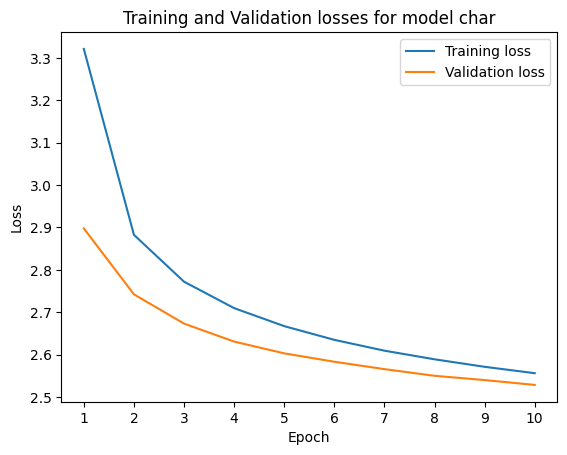

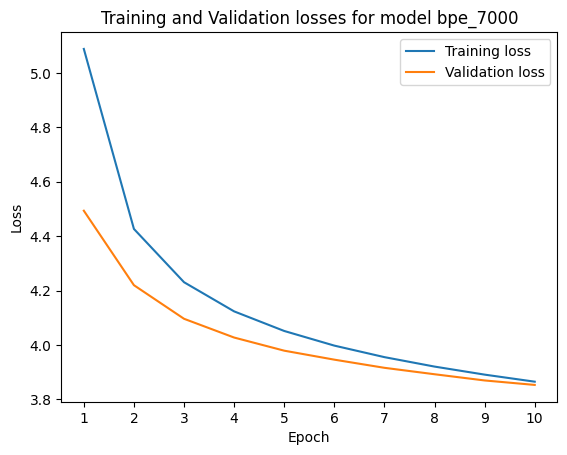

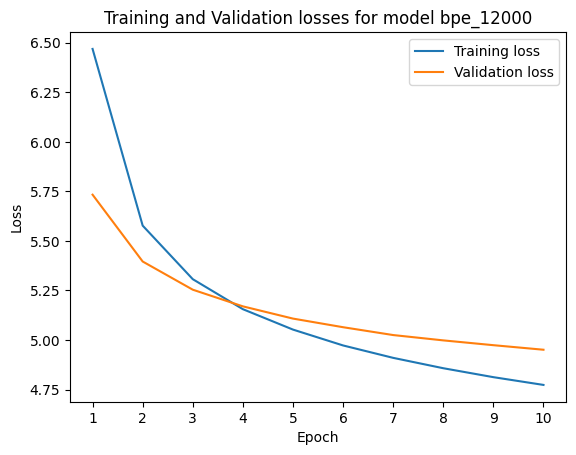

In [22]:
with open("histories.json", "r") as d:
    hist = json.load(d)

for name in ["char", "bpe_7000", "bpe_12000"]:
    records = hist[name]
    epochs = [r["epoch"] for r in records]
    train_loss = [r["train_loss"] for r in records]
    valid_loss = [r["valid_loss"] for r in records]

    plt.figure()
    plt.plot(epochs, train_loss, label = "Training loss")
    plt.plot(epochs, valid_loss, label = "Validation loss")

    plt.title(f"Training and Validation losses for model {name}")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.xticks(epochs)
    plt.legend(loc="best")
    plt.savefig(f"train and valid loss {name}", dpi=200)
    plt.show()


### Interesting observation
We see a big difference between all three models in the beginning of the plot. So even though I settled for the 7.000 BPE model instead of using a smaller one, the 12.000 BPE is much faster in learning in the beginning. Meaning the 12.000 BPE sees more characters during the same amount of text than the 7.000 BPE and the character level model. For example at the first evaluation point 12.000 BPE is around 5.1 bits per characters, 7.000 BPE at 5.4 and character at 5.55.

### Question to answer
How do the models compare with the full training data? Will the observation above still hold or will the models reach a similar perfomance? Since Chinese is less compressed in the BPE models than English and Turkish I am wondering if the BPE models will score better at BPC with English and Turkish than with Chinese. With that also: Is the BPE perfoming better with Chinese than the character level model?



### Evaluation

In [33]:
# Implementing Bits per Character

sum_loss = nn.CrossEntropyLoss(reduction="sum")

@torch.no_grad()
def BPC(model, loader, n_chars, n_tokens):
    model.eval()
    model.to(device)
    total_nats, total_tokens = 0.0, 0
    for x, y in loader:
        x,y = x.to(device), y.to(device)
        logits = model(x)
        total_nats += sum_loss(logits.reshape(-1, logits.size(-1)), y.reshape(-1)).item()
        total_tokens += y.numel()
    model.train()
    chars_per_token = n_chars / n_tokens
    bits_per_character = (total_nats/math.log(2)) / (total_tokens * chars_per_token)
    return bits_per_character


In [39]:
test_encoded_C_en = [char_encode(sentence) + [eos_C] for sentence in data["test"]["en"]]
test_encoded_C_tr = [char_encode(sentence) + [eos_C] for sentence in data["test"]["tr"]]
test_encoded_C_zh = [char_encode(sentence) + [eos_C] for sentence in data["test"]["zh"]]

test_encoded_S_en = [tokenizer_S.encode(sentence, out_type=int) + [tokenizer_S.eos_id()] for sentence in data["test"]["en"]]
test_encoded_S_tr = [tokenizer_S.encode(sentence, out_type=int) + [tokenizer_S.eos_id()] for sentence in data["test"]["tr"]]
test_encoded_S_zh = [tokenizer_S.encode(sentence, out_type=int) + [tokenizer_S.eos_id()] for sentence in data["test"]["zh"]]

test_encoded_L_en = [tokenizer_L.encode(sentence, out_type=int) + [tokenizer_L.eos_id()] for sentence in data["test"]["en"]]
test_encoded_L_tr = [tokenizer_L.encode(sentence, out_type=int) + [tokenizer_L.eos_id()] for sentence in data["test"]["tr"]]
test_encoded_L_zh = [tokenizer_L.encode(sentence, out_type=int) + [tokenizer_L.eos_id()] for sentence in data["test"]["zh"]]

test_flattened_C_en = flatten_sents(test_encoded_C_en)
test_flattened_C_tr = flatten_sents(test_encoded_C_tr)
test_flattened_C_zh = flatten_sents(test_encoded_C_zh)
test_flattened_C = test_flattened_C_en + test_flattened_C_tr + test_flattened_C_zh

test_flattened_S_en = flatten_sents(test_encoded_S_en)
test_flattened_S_tr = flatten_sents(test_encoded_S_tr)
test_flattened_S_zh = flatten_sents(test_encoded_S_zh)
test_flattened_S = test_flattened_S_en + test_flattened_S_tr + test_flattened_S_zh

test_flattened_L_en = flatten_sents(test_encoded_L_en)
test_flattened_L_tr = flatten_sents(test_encoded_L_tr)
test_flattened_L_zh = flatten_sents(test_encoded_L_zh)
test_flattened_L = test_flattened_L_en + test_flattened_L_tr + test_flattened_L_zh

BPC_C = BPC(model_C, test_loader_C, test_chars, len(test_flattened_C))
BPC_S = BPC(model_S, test_loader_S, test_chars, len(test_flattened_S))
BPC_L = BPC(model_L, test_loader_L, test_chars, len(test_flattened_L))

def BPC_per_lang(model, flat, lang):
    return BPC(model, DataLoader(BuildDataset(flat, seq_len=hyperparameters["max_seq_len"]), batch_size=batch_size), sum(len(sentence) for sentence in data["test"][lang]),len(flat))

BPC_C_en = BPC_per_lang(model_C, test_flattened_C_en, "en")
BPC_C_tr = BPC_per_lang(model_C, test_flattened_C_tr, "tr")
BPC_C_zh = BPC_per_lang(model_C, test_flattened_C_zh, "zh")

BPC_S_en = BPC_per_lang(model_S, test_flattened_S_en, "en")
BPC_S_tr = BPC_per_lang(model_S, test_flattened_S_tr, "tr")
BPC_S_zh = BPC_per_lang(model_S, test_flattened_S_zh, "zh")

BPC_L_en = BPC_per_lang(model_L, test_flattened_L_en, "en")
BPC_L_tr = BPC_per_lang(model_L, test_flattened_L_tr, "tr")
BPC_L_zh = BPC_per_lang(model_L, test_flattened_L_zh, "zh")


In [47]:
flat_lists = {
    "char": (model_C, {"en": test_flattened_C_en,"tr": test_flattened_C_tr, "zh": test_flattened_C_zh}, BPC_C),
    "BPE 7.000": (model_S, {"en": test_flattened_S_en, "tr": test_flattened_S_tr, "zh": test_flattened_S_zh}, BPC_S),
    "BPE 12.000": (model_L, {"en": test_flattened_L_en,"tr": test_flattened_L_tr, "zh": test_flattened_L_zh}, BPC_L),
}

results = {}

for name, (model, flats, overall) in flat_lists.items():
    results[name] = {lang: BPC_per_lang(model, flats[lang], lang) for lang in languages}
    results[name]["overall"] = overall
bpc_table = pandas.DataFrame(results).T.round(3)

print(bpc_table)

bpc_table.to_latex(
    "bpc_table.tex",
    index=True,
    caption="Bits per character (BPC) on the test data.",
    label="tab:bpc",
    float_format="%.3f"
)

               en     tr     zh  overall
char        2.283  2.325  6.483    3.696
BPE 7.000   2.116  2.166  6.438    3.573
BPE 12.000  2.052  2.116  6.433    3.533


The first observation is that generally both BPE models perform better than the character model with a difference from around 0.104-0.119. The larger BPE model performs better than the smaller one, but with a smaller difference of 0.015. This makes sense looking at the different results between the languages. While English and Turkish improve with the BPE, Chinese performs best with the character model.
My first prediction was that Turkish would require the most tokens. This was proven wrong on a text level. On a sentence level my prediction was correct as we can see in the table above. 
Comparing only English and Turkish my arguments about a richer morphology might be connected to what we see in the BPC. Predictions in English profit through a BPE tokenizer with a difference of 0.237-0.412 to the character tokenizer, making the difference between the two BPE models 0.175. This aligns with my prediction that a higher vocabulary would improve the performance of the BPE model. Similar things can be said for Turkish. We see a difference of 0.179-0.293 between BPE and character tokenizer. The BPC is therefore highest for the character model, this could be becasue the character tokenizer doesn't entail any information about suffixes or stems. In the same logic we see the BPE models improve with a higher vocabulary, here the difference between 12.000 and 7.000 is 0.114. Meaning the more vocabulary the tokenizer had to build common Turkish tokens, the better the model performed. Still we see that the difference between character model and BPE is bigger for English than for Turkish even though they have a similar compression. This could be explained by Turkish being richer in morphology like I mentioned in my predictions.
This also connects to the BPC scores with Chinese. Compared to the character model the BPE models get worse by 0.105-0.350 realative to the size. My lack of knowledge of this language in the beginning really showed, becasue I wasn't aware just how information rich each Chinese character is or can be. This is what sets Chinese apart from the other two languages: Chinese predictions don't improve with a higher BPE tokenizer, possibly becasue the tokenizer doesn't compress the characters much even with a higher vocabulary. This is something we can back up with the earlier table which showed characters per token going from 1 at character level to 1.25 for the 12.000 BPE.
At the same time I have to note that there is another reason to why the BPC scores for Chinese are much higher than for English and Turkish. Chinese has many more unique characters than the other two languages. We can see this in the table above. Therefore the Bits per Character is a valuable tool for comparing the different tokenizers and how they work for a specific language but we shouldn't jump to the conclusion that a model is better or worse in Chinese or English just based on a lower or higher BPC.

In [43]:
def get_vocab_count(encoded_sents):
    return collections.Counter(encoded_sents)

vocab_counts_C_en = get_vocab_count(test_flattened_C_en)
vocab_counts_C_tr = get_vocab_count(test_flattened_C_tr)
vocab_counts_C_zh = get_vocab_count(test_flattened_C_zh)
vocab_counts_C = vocab_counts_C_en + vocab_counts_C_tr + vocab_counts_C_zh

vocab_counts_S_en = get_vocab_count(test_flattened_S_en)
vocab_counts_S_tr = get_vocab_count(test_flattened_S_tr)
vocab_counts_S_zh = get_vocab_count(test_flattened_S_zh)
vocab_counts_S = vocab_counts_S_en + vocab_counts_S_tr + vocab_counts_S_zh

vocab_counts_L_en = get_vocab_count(test_flattened_L_en)
vocab_counts_L_tr = get_vocab_count(test_flattened_L_tr)
vocab_counts_L_zh = get_vocab_count(test_flattened_L_zh)
vocab_counts_L = vocab_counts_L_en + vocab_counts_L_tr + vocab_counts_L_zh

def vocab_distribution(language_count, total_count):
    token_distr = {}
    for token in language_count:
        if token in total_count:
            p = language_count[token] / total_count[token]
            token_distr[token] = p
    return token_distr

distribution_C_en = vocab_distribution(vocab_counts_C_en, vocab_counts_C)
distribution_C_tr = vocab_distribution(vocab_counts_C_tr, vocab_counts_C)
distribution_C_zh = vocab_distribution(vocab_counts_C_zh, vocab_counts_C)

distribution_S_en = vocab_distribution(vocab_counts_S_en, vocab_counts_S)
distribution_S_tr = vocab_distribution(vocab_counts_S_tr, vocab_counts_S)
distribution_S_zh = vocab_distribution(vocab_counts_S_zh, vocab_counts_S)

distribution_L_en = vocab_distribution(vocab_counts_L_en, vocab_counts_L)
distribution_L_tr = vocab_distribution(vocab_counts_L_tr, vocab_counts_L)
distribution_L_zh = vocab_distribution(vocab_counts_L_zh, vocab_counts_L)

print(distribution_C_en)
print(distribution_C_tr)
print(distribution_C_zh)

{49: 0.5074875207986689, 66: 0.40622605750231866, 62: 0.5473231503872172, 64: 0.5782198246797033, 63: 0.7606903657908295, 75: 0.4352731734308466, 61: 0.4381691426674413, 1: 0.5402132048263147, 68: 0.12456258411843876, 69: 0.34683634001594377, 76: 0.6426673932293441, 43: 0.42391947898164595, 70: 0.4084515063500199, 59: 0.4015182601559294, 82: 0.34234097464703206, 60: 0.6710971683315446, 65: 0.8141095497562375, 72: 0.6740045634219237, 73: 0.6685096153846154, 71: 0.44278531159530704, 58: 0.3921424225929365, 80: 0.9529342260732572, 77: 0.6267537303647759, 14: 0.5088998498820502, 9443: 0.2527410421611846, 45: 0.4090909090909091, 33: 0.5313887127457197, 7: 0.20235756385068762, 78: 0.43176747271301935, 50: 0.6740542606037447, 31: 0.4406454091432962, 79: 0.42969678953626633, 48: 0.48324324324324325, 37: 0.39570552147239263, 17: 0.22680255552175235, 16: 0.24539212143115288, 645: 0.67, 20: 0.19824272377814386, 12: 0.5250617719731733, 39: 0.7552195824334054, 197: 0.6666666666666666, 177: 1.0, 156

In [44]:
def summary_distribution(distribution_en, distribution_tr, distribution_zh, vocab_size):
    df = pandas.DataFrame({"en": distribution_en, "tr": distribution_tr, "zh": distribution_zh}) # each language is a column
    threshold = 0.9 # language needs to use at least 90 percent of token to "claim" it
    best = df.max(axis=1) # down the columns ergo one result per row
    category = df.idxmax(axis=1).where(best >= threshold, "shared") # getting the language name if the maximum is higher than 90 percent otherwise call it shared.
    entries = category.value_counts() # counting the total of the distribution across all languages and shared
    entries["unused"] = vocab_size - len(df) # need a category for unsused tokens as well since I am using the valid set and not the train set

    return df, entries
summary_distribution(distribution_C_en, distribution_C_tr, distribution_C_zh, vocab_size_char)

(            en        tr        zh
 49    0.507488  0.334859  0.157654
 66    0.406226  0.525082  0.068692
 62    0.547323  0.427975  0.024702
 64    0.578220  0.389975  0.031805
 63    0.760690  0.212648  0.026662
 ...        ...       ...       ...
 6569       NaN       NaN  1.000000
 7995       NaN       NaN  1.000000
 1431       NaN       NaN  1.000000
 774        NaN       NaN  1.000000
 824        NaN       NaN  1.000000
 
 [5669 rows x 3 columns],
 zh        5409
 shared     156
 tr          80
 en          24
 unused    3775
 Name: count, dtype: int64)

In [45]:
# first making a table to use for plotting
summary_table = { 
    "char": summary_distribution(distribution_C_en, distribution_C_tr, distribution_C_zh, vocab_size_char),
    "BPE 7.000": summary_distribution(distribution_S_en, distribution_S_tr, distribution_S_zh, vocab_size_S),
    "BPE 12.000": summary_distribution(distribution_L_en, distribution_L_tr, distribution_L_zh, vocab_size_L)
}
print(summary_table)

{'char': (            en        tr        zh
49    0.507488  0.334859  0.157654
66    0.406226  0.525082  0.068692
62    0.547323  0.427975  0.024702
64    0.578220  0.389975  0.031805
63    0.760690  0.212648  0.026662
...        ...       ...       ...
6569       NaN       NaN  1.000000
7995       NaN       NaN  1.000000
1431       NaN       NaN  1.000000
774        NaN       NaN  1.000000
824        NaN       NaN  1.000000

[5669 rows x 3 columns], zh        5409
shared     156
tr          80
en          24
unused    3775
Name: count, dtype: int64), 'BPE 7.000': (            en        tr        zh
57    0.506205  0.424559  0.069236
506   0.742647  0.169118  0.088235
629   0.495879  0.461538  0.042582
631   0.563101  0.359932  0.076967
268   0.664407  0.274576  0.061017
...        ...       ...       ...
4680       NaN       NaN  1.000000
4626       NaN       NaN  1.000000
6039       NaN       NaN  1.000000
5503       NaN       NaN  1.000000
5069       NaN       NaN  1.000000

[5841 

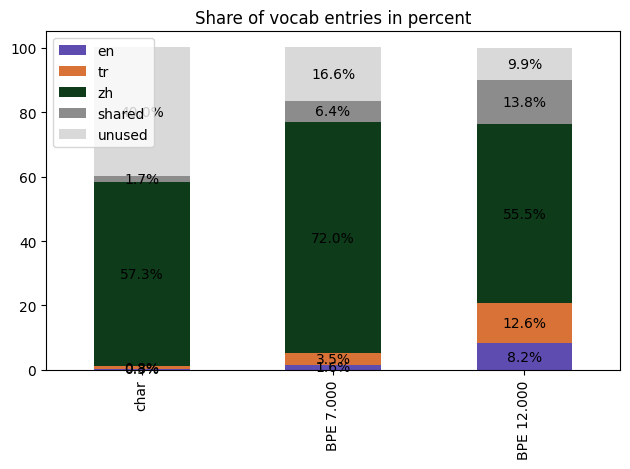

             en    tr    zh  shared  unused
char         24    80  5409     156    3775
BPE 7.000   110   242  5041     448    1159
BPE 12.000  982  1509  6658    1659    1192


In [55]:
cats = ["en", "tr", "zh", "shared", "unused"]
# accessing the total entries per model and putting them in a shared table
table_entries = pandas.DataFrame({model: summary[1] for model, summary in summary_table.items()}).T.reindex(columns=cats).fillna(0).astype(int)
# deviding by the total for each model to asnwer the question how the tokens split up over the languages for each model
pct_entries = table_entries.div(table_entries.sum(axis=1), axis=0).mul(100).round(1) 

colors = {"en": "#5E4CB0", "tr": "#D87237", "zh": "#0E3B19", "shared": "#8C8C8C", "unused": "#D9D9D9"}
ax = pct_entries.plot(kind="bar", stacked=True, title="Share of vocab entries in percent", color=[colors[c] for c in colors])

for container in ax.containers:
    ax.bar_label(container, fmt=lambda x: f"{x:.1f}%", label_type="center")

plt.tight_layout()
plt.savefig("vocab_distribution.png", dpi=200, bbox_inches="tight")
plt.show()
print(table_entries)

For this evaluation I set the treshold for vocabulary entries to be considered language-specific at 90 percent. If an entry is below that threshold it is considered to be shared. If an entry was not used to encode the test data it is considered to be unused.
Therefore when I will refer to language-specific tokens in the following analysis it doesn't mean automatically that these tokens were exclusively found in that language but that it has a share of use that is at least 90 percent. I will go through the models seperatly and highlight some inetersting points for each language.
The character model alligns with my observations becasue Chinese is clearly dominating with the most language-specific tokens. More interseting are the language-specific counts for English adn Turkish. Turkish doesn't have 80 language-specific letters so it will be interesting to print the language-specific characters for both languages and inspect them.
The smaller BPE model has a plus 15 percent higher Chinese portion but also English and Turkish have more language-specific tokens. These increases are compensated by a decrese from 40 to 16 percent share of ununsed tokens. At the same time we witness a decrease in language-specific tokens as seen in the table. This could be becasue some singular characters remained unused because a merged token containing these characters was used instead. Another reason could be that Chinese had a smaller share than 90 percent. 
Looking at the bigger BPE model English and Turkish increase their precentage. In the table we can see that this is not only a change in proportion to the other measures but also in the total counts. English has a around 9 times the number of language-specific tokens between the smaller BPE and the bigger BPE. Turkish increases its share by around 6 times. Comparing these two BPEs it looks like English is catching up with Turkish with a bigger BPE size while remaining the language with the least amount of language-specific tokens. That observation is also not surprising when we see that the character model has around 2.5 times the amount of Turkish characters than English (with Chinese being far ahead). The interesting observation for Chinese is the difference between the two BPEs. The bigger BPE increases the amount of language-specific Chinese tokens which could be explained by a more merges. But still English and Turkish increase as well as the amount of shared tokens. This contributes to the impression that the bigger BPE is wokring towards evening out the numbers that we see on the character level. 
We can bring these findings together with the insights using the BPC. The improvement of the performance from character over smaller BPE to bigger BPE that we saw in the BPC measure for English and Turkish connect well to their increase of language-specific token representation we see here. 
